In [3]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import fashion_mnist

# データの読み込みと前処理
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# リストの後ろからN個の要素を削除
x_train = x_train[:-58000]
y_train = y_train[:-58000]

# 画像サイズを 32x32 にリサイズし、1チャンネルに
x_train = tf.image.resize(tf.expand_dims(x_train, -1), (32, 32)) / 255.0
x_test = tf.image.resize(tf.expand_dims(x_test, -1), (32, 32)) / 255.0

y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

# ViT のパラメータ
image_size = 32  # 画像の高さ/幅
patch_size = 4  # パッチサイズ
num_patches = (image_size // patch_size) ** 2  # パッチ数
projection_dim = 64  # 埋め込みの次元
num_heads = 2 # マルチヘッドアテンションのヘッド数
transformer_layers = 5  # Transformer ブロック数


def self_attention(x, num_heads, projection_dim):

    attention_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=projection_dim)(x, x)

    #第1引数 → Query
    #第2引数 → Key / Value
    #自己注意なので、同じ引数になる
    #これはマルチヘッド（num_heads数の自己注意）であり、かつconcat関数でそれらをシンプルにつなぎ合わせている
    #よってprojection_dim次元の入力ベクトルからnum_heads*projection_dim次元の出力ベクトルが生成される
    #それに対して、Kerasでは、全結合層を施しており、そのことによってprojection_dim次元のベクトルに引き戻している

    x1 = layers.Add()([x, attention_output])  # 残差接続（ただ足してるだけ）


    return x1

def create_vit(input_shape, num_classes):
    """Simple ViT Model"""
    inputs = layers.Input(shape=input_shape)

    # パッチ分割 (画像を小さいブロックに変換)
    patches = layers.Conv2D(projection_dim, kernel_size=patch_size, strides=patch_size, padding="valid")(inputs)
    #projection_dim個の積分核を用意し、projection_dim回の合成積を施す
    #kernel_size（積分核の縦横サイズ）とstrides（積分核の縦横移動幅）が同じなので、これは画像を小さいブロックに分割していることを意味する
    patches = layers.Reshape((num_patches, projection_dim))(patches)

    # 位置エンコーディング
    positions = tf.range(start=0, limit=num_patches)
    position_embedding = layers.Embedding(input_dim=num_patches, output_dim=projection_dim)(positions)
    #学習可能なprojection_dimのベクトルを生成
    position_embedding = tf.expand_dims(position_embedding, axis=0)  # データ型の調整
    x = patches + position_embedding

    # Transformer Encoder を適用
    for _ in range(transformer_layers):
        x = self_attention(x, num_heads, projection_dim)

    x = layers.Flatten()(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return keras.Model(inputs, outputs)

# モデルの作成
model = create_vit(input_shape=(32, 32, 1), num_classes=10)

# モデルのコンパイル
model.compile(optimizer=keras.optimizers.Adam(),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# モデルの学習
epochs = 1
batch_size = 4
history = model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_data=(x_test, y_test))

# モデルの評価
score = model.evaluate(x_test, y_test, verbose=1)
print('\nTest loss:', score[0])
print('Test accuracy:', score[1])


500/500 ━━━━━━━━━━━━━━━━━━━━ 26s 42ms/step - accuracy: 0.6805 - loss: 0.9100 - val_accuracy: 0.7264 - val_loss: 0.7564
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - accuracy: 0.7264 - loss: 0.7564

Test loss: 0.7564173936843872
Test accuracy: 0.7264000177383423


313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step


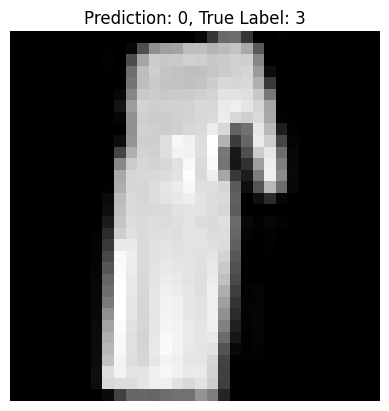

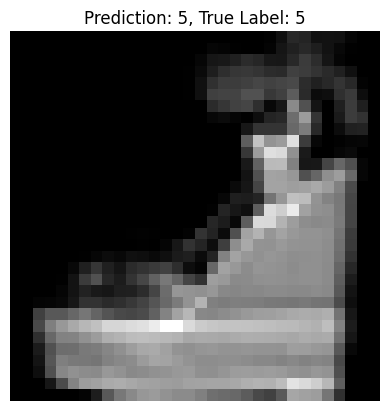

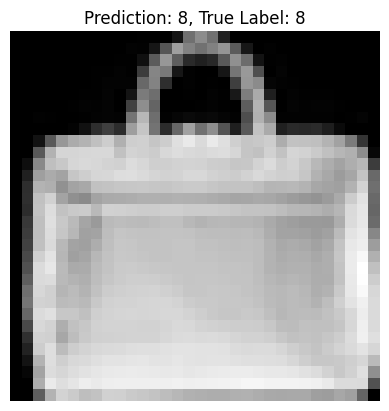

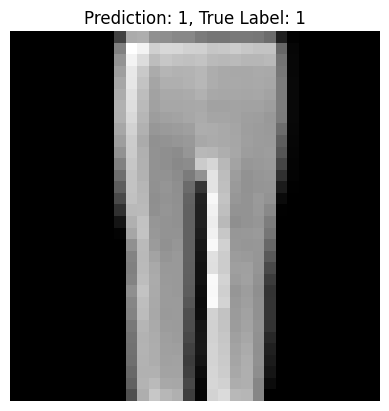

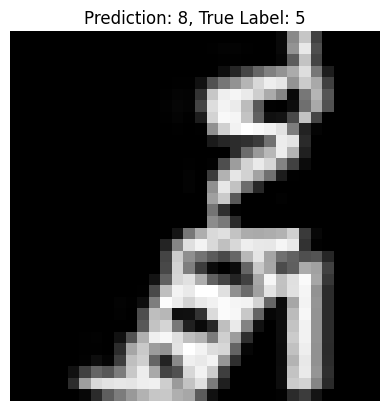

In [4]:

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

# テストデータに対する予測を取得
predictions = model.predict(x_test)
predictions = predictions if isinstance(predictions, np.ndarray) else predictions.numpy()  # NumPy に変換

# x_test が Tensor の場合、NumPy 配列に変換
x_test = x_test if isinstance(x_test, np.ndarray) else x_test.numpy()

# いくつかの画像をランダムに選択
num_images_to_show = 5
random_indices = np.random.choice(len(x_test), size=num_images_to_show, replace=False)

# 画像と予測結果を表示
for i in random_indices:
    plt.imshow(x_test[i].squeeze(), cmap='gray')  # (32, 32, 1) → (32, 32) に変換
    plt.title(f'Prediction: {np.argmax(predictions[i])}, True Label: {np.argmax(y_test[i])}')
    plt.axis("off")  # 軸を非表示に
    plt.show()
